In [1]:
import sys
print(sys.path)

['/usr/local/lib/python311.zip', '/usr/local/lib/python3.11', '/usr/local/lib/python3.11/lib-dynload', '', '/home/vscode/.local/lib/python3.11/site-packages', '/usr/local/lib/python3.11/site-packages']


In [2]:
import os
sys.path.append(os.path.abspath(".."))

In [3]:
import importlib
from resources import psiBfield

importlib.reload(psiBfield)

g = psiBfield.extract_g()
psi_norm, BR, Bphi, BZ = psiBfield.compute_B(g)

g_file keywords extracted
Psi Normalized and Magnetic field BR Bphi BZ computed.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.optim as optim

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [6]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [7]:
g.r_grid

array([[0.84      , 0.84      , 0.84      , ..., 0.84      , 0.84      ,
        0.84      ],
       [0.85328125, 0.85328125, 0.85328125, ..., 0.85328125, 0.85328125,
        0.85328125],
       [0.8665625 , 0.8665625 , 0.8665625 , ..., 0.8665625 , 0.8665625 ,
        0.8665625 ],
       ...,
       [2.5134375 , 2.5134375 , 2.5134375 , ..., 2.5134375 , 2.5134375 ,
        2.5134375 ],
       [2.52671875, 2.52671875, 2.52671875, ..., 2.52671875, 2.52671875,
        2.52671875],
       [2.54      , 2.54      , 2.54      , ..., 2.54      , 2.54      ,
        2.54      ]], shape=(129, 129))

In [8]:
r = np.concatenate(g.r_grid)
print(r.shape)

(16641,)


In [9]:
z = np.concatenate(g.z_grid)
X_train = np.column_stack((r, z))
Y_train = np.concatenate(psi_norm)
BR_train  = np.concatenate(BR)
BZ_train = np.concatenate(BZ)

In [10]:
# NN
class PsiNN(nn.Module):
  def __init__(self):
    super(PsiNN, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(2, 512),
        nn.Tanh(),
        nn.Linear(512, 512),
        nn.Tanh(),
        nn.Linear(512, 1)

    )
  def forward(self, x):
    return self.model(x)

In [11]:
# Initialize model, loss, and optimizer
model_psi = PsiNN()
fn_Loss = nn.MSELoss()
model_psi.to(device)
optimizer = optim.Adam(model_psi.parameters(), lr=0.001)

In [12]:
Y_train.dtype

dtype('float64')

In [13]:
Y_train = Y_train.reshape(-1,1)
Y_train.shape

(16641, 1)

In [14]:
# Move X_train to the device as well
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
# Move y_train to the device as well
Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)

# Training loop
epochs = 10001
for epoch in range(epochs):
  model_psi.train()
  Y_preds = model_psi(X_train)
  loss = fn_Loss(Y_preds, Y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.4043930172920227
Epoch 100, Loss: 0.017994724214076996
Epoch 200, Loss: 0.012166904285550117
Epoch 300, Loss: 0.005719518754631281
Epoch 400, Loss: 0.002682826481759548
Epoch 500, Loss: 0.0017803541850298643
Epoch 600, Loss: 0.0013485829113051295
Epoch 700, Loss: 0.0011219048174098134
Epoch 800, Loss: 0.0009918631985783577
Epoch 900, Loss: 0.0009098507580347359
Epoch 1000, Loss: 0.0008520249393768609
Epoch 1100, Loss: 0.000804669689387083
Epoch 1200, Loss: 0.0007614294881932437
Epoch 1300, Loss: 0.0007217550300993025
Epoch 1400, Loss: 0.0006875555263832211
Epoch 1500, Loss: 0.0006567636737599969
Epoch 1600, Loss: 0.000627814675681293
Epoch 1700, Loss: 0.0006000291323289275
Epoch 1800, Loss: 0.0005732154822908342
Epoch 1900, Loss: 0.0005473907222039998
Epoch 2000, Loss: 0.0005223663174547255
Epoch 2100, Loss: 0.0004976323107257485
Epoch 2200, Loss: 0.000482164352433756
Epoch 2300, Loss: 0.00045249031973071396
Epoch 2400, Loss: 0.0008914840291254222
Epoch 2500, Loss: 0.0

In [15]:
# Training



In [16]:
# Compute final MSE loss
model_psi.eval()
with torch.no_grad():
  Y_final = model_psi(X_train)
  loss = fn_Loss(Y_final, Y_train)
  loss_psi_vanilla = loss.item() * 100
  print(f"Final MSE Loss for (R, Z) -> psi (in %): {loss_psi_vanilla}")

Final MSE Loss for (R, Z) -> psi (in %): 0.13790464727208018


In [17]:
psi = Y_final.reshape(129,129)

In [ ]:
def plot(R ,Z, psi_preds, title):
  plt.contourf(R, Z, psi_preds,  cmap = 'plasma')
  plt.colorbar()
  plt.xlim([R[0],R[-1]])
  plt.ylim([Z[0],Z[-1]])
  plt.xlabel('R [m]')
  plt.ylabel('Z [m]')
  plt.axis('equal')
  plt.title(title)

/tmp/ipykernel_3246/4280469088.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plot_psi(g.r_grid[:, 0], g.z_grid[0, :], (abs(psi-psi_norm)*100).T, title=r"$\psi(R, Z)_{error}$")


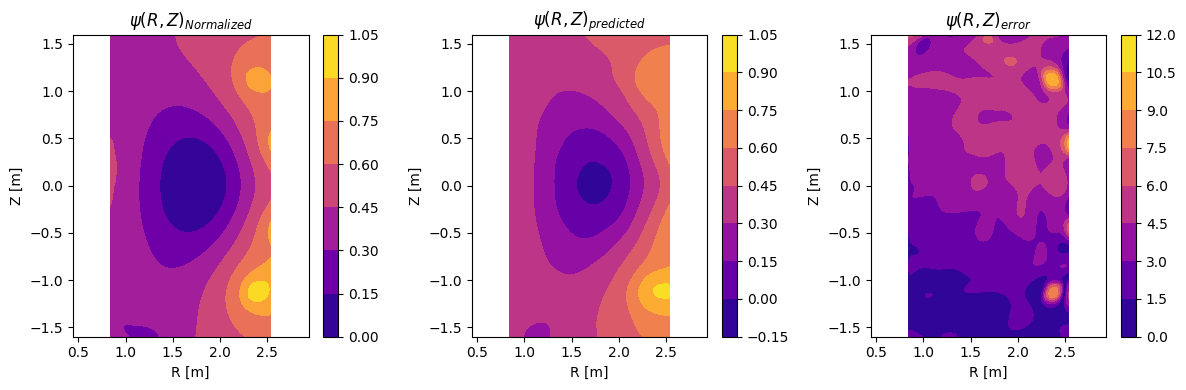

In [ ]:
fig = plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plot(g.r_grid[:, 0] ,g.z_grid[0, :], psi_norm.T, title = r"$\psi(R,Z)_{Normalized}$")

plt.subplot(1,3,2)
plot(g.r_grid[:, 0] ,g.z_grid[0, :], psi.T, title = r"$\psi(R,Z)_{predicted}$")

plt.subplot(1,3,3)
plot(g.r_grid[:, 0], g.z_grid[0, :], (abs(psi-psi_norm)*100).T, title=r"$\psi(R, Z)_{error}$")

plt.tight_layout()
plt.show()